# Confidence Intervals in Data Analytics


Implement the 4 steps that we learnt regarding distributions namely:

1. Understand the Data Type: Continuous or discrete.
2. Identify the Analytical Question: Determine which distribution fits your question.
3. Calculate Descriptive Statistics: Compute and visualize summary statistics.
4. Interpret the Graph and Descriptive Statistics: Analyze the data’s distribution and patterns.

To ultimately calculate the CI.

Keep in mind to check the following when selecting the method to calculate CI:

- Sample Size
- Population Parameters are known or unknown

---

# Case Study 1:

Scenario:
A call center wants to estimate the average number of calls received per hour. A random sample of 40 hours is selected, and the number of calls received each hour is recorded. The number of calls follows a Poisson distribution, as it is a count of events within a fixed period. The population mean and variance are unknown.

Your task is to calculate the 95% confidence interval for the mean number of calls received per hour.

Dataset: calls_per_hour


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
df = pd.read_csv("data/calls_per_hour.csv")

In [3]:
df

,CallsPerHour
0,5
1,4
2,4
3,5
4,5
5,3
6,5
7,4
8,6
9,7


In [4]:
sample_mean = df['CallsPerHour'].mean()
sample_std = df['CallsPerHour'].std()
sample_median = df['CallsPerHour'].median()
n = len(df)

print(f"Calls per hour mean: {sample_mean:.2f}")
print(f"Calls per hour standard deviation: {sample_std:.2f}")
print(f"Calls per hour median: {sample_median:.2f}")

Calls per hour mean: 4.92
Calls per hour standard deviation: 2.21
Calls per hour median: 5.00


In [14]:
import pandas as pd
from scipy.stats import chi2

# Load data
df = pd.read_csv("data/calls_per_hour.csv")

# Check column names
print(df.columns)

# Function to calculate exact Poisson 95% CI
def poisson_ci(k, alpha=0.05):
    lower = 0 if k == 0 else 0.5 * chi2.ppf(alpha/2, 2*k)
    upper = 0.5 * chi2.ppf(1 - alpha/2, 2*(k+1))
    return lower, upper

# Apply function to the relevant column
df['CI_lower'], df['CI_upper'] = zip(*df['CallsPerHour'].apply(poisson_ci))

# Apply function and expand the results into two columns
# df[['CI_lower', 'CI_upper']] = df['CallsPerHour'].apply(lambda k: pd.Series(poisson_ci(k)))

# Round CI_lower and CI_upper to 2 decimal places
df[['CI_lower', 'CI_upper']] = df[['CI_lower', 'CI_upper']].round(2)

# Show results
df

Index(['CallsPerHour'], dtype='object')


,CallsPerHour,CI_lower,CI_upper
0,5,1.62,11.67
1,4,1.09,10.24
2,4,1.09,10.24
3,5,1.62,11.67
4,5,1.62,11.67
5,3,0.62,8.77
6,5,1.62,11.67
7,4,1.09,10.24
8,6,2.20,13.06
9,7,2.81,14.42


---

# Case Study 2: Interpreting Confidence Interval for Customer Satisfaction
Scenario:
You are a data analyst at a retail company, and your team conducted a survey to measure customer satisfaction with your online shopping platform. 

The survey asked customers to rate their overall satisfaction on a scale from 1 to 10, where 1 means "very dissatisfied" and 10 means "very satisfied."

After analyzing the responses from a random sample of 150 customers, the team calculated a 95% confidence interval for the mean satisfaction score, which is (7.2, 8.1).

```Task:
Your task is to interpret this confidence interval in the context of the survey results. Specifically, answer the following questions:

What does the confidence interval tell you about the average satisfaction score of all customers?

Can you confidently say that customers are generally satisfied with the online shopping platform? Why or why not?

How would you present these results to the company’s management team?
```

In [15]:
# The confidence interval (7.2, 8.1) provides a range in which we are 95% confident that the true average customer satisfaction score lies. 

# This means that, based on the sample data, the actual average customer satisfaction score could be as low as 7.2 or as high as 8.1.

In [16]:
# No, you cannot confidently say that the customers are generally satisfied with the online shopping platform. 
# While the lower bound of the confidence interval (7.2) means that the customers are satisfied but not enthusiastic.
# Customers had a decent experience, but they wouldn’t go out of their way to recommend the company.
# the upper bound (8.1) means that the experience was good, met expectations, but maybe not amazing.

In [17]:
# Our study shows that the average customer satisfaction score likely falls between 7.2 and 8.1,
# which means that the experience was good, met expectations, but maybe not amazing.
# Therefore, it is important to consider strategies that improve customer experience so that they can be loyal and recommend the brand.

---

# Case Study 3: Iris Data set
For the Iris data set, calculate the 95% confidence intervals for the mean of the Length of the petal of Iris Setosa feature using bootstrapping. Create a notebook in which following questions shall be solved:

1. Initialize empty list called sample_means
2. Create a for loop that will loop 10,000 times
3. In each iteration using the pandas method .sample() sample 100 profits with replacement
4. Also in that same iteration take the mean of these 100 samples and then append it to the sample_means list
5. Using sns.displot plot the distribution of the sample_means list
6. Convert sample_means list to pandas Series
7. Using pandas .quantile() calculate the upper (0.975) and lower (0.025) limits of the confidence interval of the sample_means Series

### Bonus

8. Calculate using the z-value formula
9. Compare to the results of the bootstrapping method

In [19]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [21]:
# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)


In [22]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Sample average petal length (cm): 3.76
95% Confidence Interval for the average petal length: (3.41, 4.11)


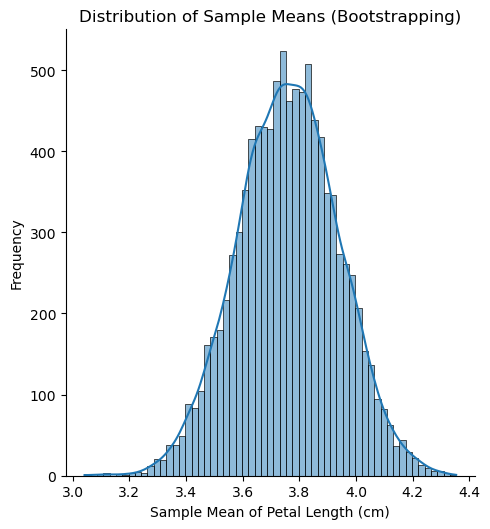

In [ ]:
# using bootstrapping: create a function

# Step 1: Calculate the sample petal length mean
sample_mean = iris_df['petal length (cm)'].mean()
print(f"Sample average petal length (cm): {sample_mean:.2f}")

# Step 2: Define a bootstrapping function to calculate the CI
def bootstrap_ci(data, n, num_bootstrap=10000, confidence_level=0.95):
    bootstrapped_means = []
    for _ in range(num_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrapped_means.append(np.mean(sample))
    
    # CI bounds
    lower_bound = np.percentile(bootstrapped_means, (1 - confidence_level) / 2 * 100)
    upper_bound = np.percentile(bootstrapped_means, (1 + confidence_level) / 2 * 100)
    return lower_bound, upper_bound, bootstrapped_means

# Step 3: Ask for sample size once
n = int(input("Please enter the sample size: "))

# Step 4: Run bootstrapping
ci_lower, ci_upper, bootstrapped_means = bootstrap_ci(
    iris_df['petal length (cm)'], n=n, num_bootstrap=10000, confidence_level=0.95
)

print(f"95% Confidence Interval for the average petal length: ({ci_lower:.2f}, {ci_upper:.2f})")

# Step 5: Plot distribution
sns.displot(bootstrapped_means, kde=True)
plt.title('Distribution of Sample Means (Bootstrapping)')
plt.xlabel('Sample Mean of Petal Length (cm)')
plt.ylabel('Frequency')
plt.show()


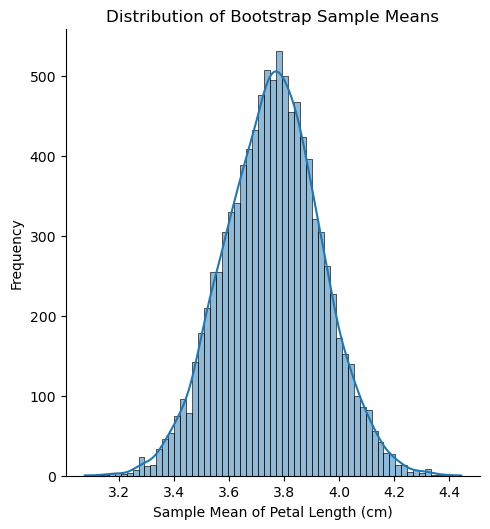

95% Confidence Interval for the mean: (3.41, 4.11)


In [ ]:
# using bootstrapping: for-loop

# 1. Initialize empty list
sample_means = []

# 2. Create a loop 10,000 times
for _ in range(10000):
    # 3. Sample 100 profits with replacement
    sample = iris_df['petal length (cm)'].sample(n=100, replace=True)
    
    # 4. Take the mean and append to the list
    sample_means.append(sample.mean())

# 5. Plot the distribution
sns.displot(sample_means, kde=True)
plt.title('Distribution of Bootstrap Sample Means')
plt.xlabel('Sample Mean of Petal Length (cm)')
plt.ylabel('Frequency')
plt.show()

# 6. Convert list to pandas Series
sample_means_series = pd.Series(sample_means)

# 7. Calculate 95% CI using quantiles
ci_lower = sample_means_series.quantile(0.025)
ci_upper = sample_means_series.quantile(0.975)

print(f"95% Confidence Interval for the mean: ({ci_lower:.2f}, {ci_upper:.2f})")


In [35]:
# using z distribution: normal distribution

sample_mean = iris_df['petal length (cm)'].mean()
sample_std = iris_df['petal length (cm)'].std()
sample_median = iris_df['petal length (cm)'].median()
n = len(iris_df)

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"Sample Median: {sample_median:.2f}")

Sample Mean: 3.76
Sample Standard Deviation: 1.77
Sample Median: 4.35


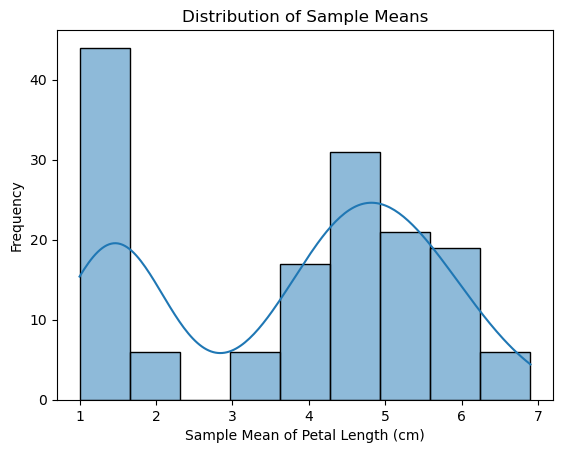

In [37]:
# Visualize the distribution
sns.histplot(iris_df['petal length (cm)'], kde=True)
plt.title("Distribution of Sample Means")
plt.xlabel("Sample Mean of Petal Length (cm)")
plt.ylabel("Frequency")
plt.show()

In [38]:
iris_df['petal length (cm)'].skew() # Checking skewness value  well within the expected bounds of  -0.5 and +0.5

np.float64(-0.27488417975101276)

In [ ]:
#standard deviation: SD
#standard error: SE=​σ/sqrt(n)​
#margin of error ME=z∗⋅SE
# Z score: 95% (1.96)
# 1.77 = SD (σ) : in this case
# 1.77 / sqrt(n) = SE 
# Z × SE = Margin of Error


#Finds the critical Z-value for a 95% CI (z_score = 1.96).
#Computes the margin of error as 1.96×1.77/sqrt(n)
#Builds the interval[xˉ−ME,  xˉ+ME]


In [42]:
# 95% CI meaning we want to capture the middle 95% of the data. This leaves 5% of the data i.e. 2.5% on either tail
# Hence why we use .975 to establish upper bound of the CI and lower bound

from scipy.stats import norm

z_score = norm.ppf(0.975) # Z-score since the data is normal and population params are known
margin_of_error = z_score * (1.77 / np.sqrt(n))  # 1.77 is the standard error 
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"95% Confidence Interval for the Mean Dosage Strength: ({ci_lower:.2f}, {ci_upper:.2f})")

95% Confidence Interval for the Mean Dosage Strength: (3.47, 4.04)
